In [3]:
import subprocess
from pathlib import Path

repo_dir = Path(".").resolve()

result = subprocess.run(
    ["julia", "compare_nonuniform_embedding_quality.jl"],
    cwd=repo_dir,
    capture_output=True,
    text=True,
    encoding="utf-8"
)

print(result.stdout)
print(result.stderr)

Рядов в Pecuzal: 26
Рядов в Pecora: 26
Общих рядов: 26
Всего строк параметров: 52
Готово: Lab1_G1_N3                pecuzal  dim= 1 lags=0                    | NRMSE=1.5177 | noise_dist=0.0518
Готово: Lab1_G2_Fн9               pecuzal  dim= 2 lags=0;2                  | NRMSE=1.3963 | noise_dist=0.0347
Готово: Lab1_G2_Fc3               pecuzal  dim= 1 lags=0                    | NRMSE=1.2994 | noise_dist=0.0472
Готово: Lab1_G1_N1                pecuzal  dim= 2 lags=0;107                | NRMSE=0.5085 | noise_dist=0.0379
Готово: Lab1_G1_N2                pecuzal  dim= 2 lags=0;81                 | NRMSE=0.5834 | noise_dist=0.0393
Готово: Lab1_G2_3F2               pecuzal  dim= 1 lags=0                    | NRMSE=1.4565 | noise_dist=0.0498
Готово: Lab1_G1_T4ср              pecuzal  dim= 5 lags=0;76;99;117;140      | NRMSE=0.6745 | noise_dist=0.0291
Готово: Lab1_G3_T606              pecuzal  dim= 8 lags=0;8;18;28;49;74;97;134 | NRMSE=0.6619 | noise_dist=0.0209
Готово: Lab1_Qtg            

## Оценка качества вложения с неравномерными задержками

В случае неравномерного вложения вместо одной фиксированной задержки $\tau$ используется набор задержек:

$$
L = \{l_1, l_2, \dots, l_m\}
$$

где:

- $L$ — набор выбранных задержек;
- $l_i$ — отдельная задержка;
- $m$ — размерность вложения.

Для каждого временного ряда сравниваются два метода выбора неравномерных задержек: `Pecuzal` и `Pecora`.

---

### 1. Построение неравномерного delay embedding

Пусть исходный временной ряд задан как:

$$
x_1, x_2, \dots, x_N
$$

Для заданного набора задержек:

$$
L = \{l_1, l_2, \dots, l_m\}
$$

строится embedding-вектор:

$$
X_t =
\left(
x_{t+l_1},
x_{t+l_2},
\dots,
x_{t+l_m}
\right)
$$

Здесь:

- $X_t$ — точка во вложенном фазовом пространстве;
- $l_1, l_2, \dots, l_m$ — выбранные неравномерные задержки;
- $m$ — размерность вложения.

В отличие от равномерного вложения, задержки не обязаны идти с постоянным шагом:

$$
0, \tau, 2\tau, \dots, (m-1)\tau
$$

Они могут быть произвольными, например:

$$
L = \{0, 3, 1, 2, 5\}
$$

Тогда embedding-вектор имеет вид:

$$
X_t =
\left(
x_t,
x_{t+3},
x_{t+1},
x_{t+2},
x_{t+5}
\right)
$$

---

### 2. Допустимые значения индекса $t$

Поскольку в embedding-вектор входят значения с разными задержками, максимальная задержка определяется как:

$$
l_{\max} = \max(L)
$$

Чтобы не выйти за границы временного ряда, индекс $t$ должен удовлетворять условию:

$$
t + l_{\max} + h \leq N
$$

Отсюда:

$$
t = 1, 2, \dots, N - l_{\max} - h
$$

где:

- $N$ — длина временного ряда;
- $l_{\max}$ — максимальная задержка;
- $h$ — горизонт прогноза.

В данной проверке используется:

$$
h = 1
$$

то есть прогнозируется следующее значение после самой дальней координаты embedding-вектора.

---

### 3. Целевое значение для реконструкции динамики

Целевое значение определяется как значение ряда через $h$ шагов после максимальной задержки:

$$
y_t =
x_{t+l_{\max}+h}
$$

При $h = 1$:

$$
y_t =
x_{t+l_{\max}+1}
$$

Таким образом, по вектору состояния $X_t$ модель пытается восстановить ближайшее будущее значение ряда.

---

### 4. Ошибка реконструкции

Если вложение построено качественно, то близкие точки во вложенном пространстве должны иметь похожее будущее.

Для каждой тестовой точки $X_t$ находятся $k$ ближайших соседей:

$$
\mathcal{N}_k(X_t) =
\{X_{j_1}, X_{j_2}, \dots, X_{j_k}\}
$$

Расстояние между точками считается в евклидовой метрике:

$$
\rho(X_t, X_j)
=
\|X_t - X_j\|_2
$$

Прогноз строится как взвешенное среднее будущих значений ближайших соседей:

$$
\hat{y}_t =
\frac{
\sum\limits_{j \in \mathcal{N}_k(X_t)} w_j y_j
}{
\sum\limits_{j \in \mathcal{N}_k(X_t)} w_j
}
$$

где вес соседа обратно пропорционален расстоянию до него:

$$
w_j =
\frac{1}{\rho(X_t, X_j) + \varepsilon}
$$

Здесь $\varepsilon$ — малое число, добавленное для предотвращения деления на ноль.

Ошибка прогноза:

$$
e_t =
y_t - \hat{y}_t
$$

MAE:

$$
MAE =
\frac{1}{n}
\sum_{t=1}^{n}
|y_t - \hat{y}_t|
$$

RMSE:

$$
RMSE =
\sqrt{
\frac{1}{n}
\sum_{t=1}^{n}
(y_t - \hat{y}_t)^2
}
$$

Нормированная ошибка реконструкции:

$$
NRMSE =
\frac{RMSE}{\operatorname{std}(y)}
$$

Чем меньше $NRMSE$, тем лучше вложение сохраняет локальную динамику временного ряда.

---

### 5. Добавление шума

Для оценки устойчивости вложения к шуму к исходному ряду добавляется искусственный шум:

$$
x_t^{noise}
=
x_t + \eta_t
$$

где:

$$
\eta_t \sim \mathcal{N}(0, \sigma_{noise}^2)
$$

Стандартное отклонение шума задается относительно стандартного отклонения исходного ряда:

$$
\sigma_{noise}
=
\alpha \cdot \operatorname{std}(x)
$$

где $\alpha$ — уровень шума.

В эксперименте используется:

$$
\alpha = 0.05
$$

То есть к ряду добавляется шум с уровнем примерно 5% от стандартного отклонения исходного ряда.

Для зашумленного ряда строится вложение с теми же неравномерными задержками:

$$
X_t^{noise}
=
\left(
x_{t+l_1}^{noise},
x_{t+l_2}^{noise},
\dots,
x_{t+l_m}^{noise}
\right)
$$

---

### 6. Ошибка смещения точек из-за шума

Первая шумовая метрика показывает, насколько сильно точки во вложенном пространстве смещаются после добавления шума.

Для каждой точки считается расстояние между исходным и зашумленным embedding-вектором:

$$
s_t =
\|X_t - X_t^{noise}\|_2
$$

Среднее смещение:

$$
\overline{s}
=
\frac{1}{n}
\sum_{t=1}^{n}
\|X_t - X_t^{noise}\|_2
$$

Чтобы не штрафовать вложения большей размерности только за то, что у них больше координат, смещение нормируется на стандартное отклонение ряда и корень из размерности:

$$
E_{shift}
=
\frac{
\frac{1}{n}
\sum\limits_{t=1}^{n}
\|X_t - X_t^{noise}\|_2
}{
\operatorname{std}(x)\sqrt{m}
}
$$

Чем меньше $E_{shift}$, тем устойчивее положение точек во вложенном пространстве к шуму.

---

### 7. Искажение попарных расстояний

Вторая шумовая метрика показывает, насколько шум меняет геометрию вложенного пространства.

Для исходного вложения строится матрица попарных расстояний:

$$
D_{ij}
=
\|X_i - X_j\|_2
$$

Для зашумленного вложения строится аналогичная матрица:

$$
D_{ij}^{noise}
=
\|X_i^{noise} - X_j^{noise}\|_2
$$

Затем считается относительное искажение матрицы расстояний:

$$
E_D
=
\frac{
\|D - D^{noise}\|_F
}{
\|D\|_F
}
$$

где $\|\cdot\|_F$ — норма Фробениуса:

$$
\|D\|_F =
\sqrt{
\sum_i \sum_j D_{ij}^2
}
$$

Чем меньше $E_D$, тем лучше вложение сохраняет геометрическую структуру фазового пространства при добавлении шума.

---

### 8. Усреднение по нескольким шумовым запускам

Так как шум генерируется случайно, проверка проводится несколько раз.

Пусть количество запусков равно $R$. Тогда итоговая ошибка смещения точек:

$$
E_{shift}^{mean}
=
\frac{1}{R}
\sum_{r=1}^{R}
E_{shift}^{(r)}
$$

И итоговое искажение расстояний:

$$
E_D^{mean}
=
\frac{1}{R}
\sum_{r=1}^{R}
E_D^{(r)}
$$

В эксперименте используется:

$$
R = 10
$$

---

### 9. Нормализация метрик

Для итогового сравнения используются три метрики:

$$
NRMSE
$$

$$
E_{shift}^{mean}
$$

$$
E_D^{mean}
$$

Так как эти величины имеют разный масштаб, каждая метрика нормируется методом min-max:

$$
z_i =
\frac{
q_i - q_{\min}
}{
q_{\max} - q_{\min}
}
$$

где:

- $q_i$ — значение метрики для конкретного вложения;
- $q_{\min}$ — минимальное значение этой метрики среди всех рассматриваемых вложений;
- $q_{\max}$ — максимальное значение этой метрики среди всех рассматриваемых вложений.

После такой нормализации все метрики приводятся к диапазону $[0, 1]$.

---

### 10. Итоговый quality score

Итоговое качество вложения считается как среднее значение трех нормированных ошибок:

$$
QualityScore =
\frac{
NRMSE_{norm}
+
E_{shift,norm}
+
E_{D,norm}
}{3}
$$

Чем меньше значение $QualityScore$, тем лучше считается вложение.

Меньшее значение означает, что вложение одновременно:

- лучше восстанавливает локальную динамику временного ряда;
- меньше смещается при добавлении шума;
- лучше сохраняет геометрию попарных расстояний в фазовом пространстве.

---

### 11. Интерпретация сравнения методов Pecuzal и Pecora

Для каждого ряда сравниваются два значения:

$$
QualityScore_{Pecuzal}
$$

и

$$
QualityScore_{Pecora}
$$

Если:

$$
QualityScore_{Pecuzal}
<
QualityScore_{Pecora}
$$

то для данного ряда более качественным считается вложение, полученное методом `Pecuzal`.

Если:

$$
QualityScore_{Pecora}
<
QualityScore_{Pecuzal}
$$

то более качественным считается вложение, полученное методом `Pecora`.

Также можно рассматривать разность:

$$
\Delta Q =
QualityScore_{Pecuzal}
-
QualityScore_{Pecora}
$$

Тогда:

$$
\Delta Q < 0
$$

означает, что лучше `Pecuzal`, а

$$
\Delta Q > 0
$$

означает, что лучше `Pecora`.

## Визуализация

Количество строк по методам:
method
pecora     26
pecuzal    26
Name: count, dtype: int64

Количество уникальных рядов по методам:
method
pecora     26
pecuzal    26
Name: column, dtype: int64

Дубли по column + method:


,column,method,count



Сводка по методам:


,method,mean_reconstruction_nrmse,mean_noise_point_shift,mean_noise_distance_distortion,mean_quality_score,n_rows
0,pecora,0.728793,0.047912,0.022102,0.431549,26
1,pecuzal,1.067931,0.045044,0.032825,0.464695,26



Всего строк в исходном full: 52
Общих рядов, где есть оба метода: 26
Строк после фильтрации: 52

Количество строк по методам после фильтрации:
method
pecora     26
pecuzal    26
Name: count, dtype: int64

Количество уникальных рядов по методам после фильтрации:
method
pecora     26
pecuzal    26
Name: column, dtype: int64


,column,method,dimension,lags_str,cost,reconstruction_nrmse,noise_point_shift,noise_distance_distortion,quality_score
0,Lab1_G1_N1,pecora,5,0;17;8;4;2,NaN,0.465749,0.047791,0.021518,0.384805
1,Lab1_G1_N1,pecuzal,2,0;107,-0.171054,0.508515,0.044502,0.037885,0.402542
2,Lab1_G1_N2,pecora,6,0;13;6;3;2;1,NaN,0.460655,0.048225,0.019642,0.384644
3,Lab1_G1_N2,pecuzal,2,0;81,-0.578048,0.583382,0.044469,0.039296,0.422813
4,Lab1_G1_N3,pecora,4,0;1;4;2,NaN,1.075617,0.047189,0.025607,0.483971
5,Lab1_G1_N3,pecuzal,1,0,0.000000,1.517671,0.040001,0.051792,0.502474
6,Lab1_G1_T1,pecora,5,0;14;4;2;1,NaN,0.439438,0.047856,0.022116,0.387569
7,Lab1_G1_T1,pecuzal,3,0;50;107,-0.343739,0.521475,0.046325,0.031898,0.420933
8,Lab1_G1_T4ср,pecora,6,0;17;7;4;2;1,NaN,0.547089,0.048188,0.020149,0.399795
9,Lab1_G1_T4ср,pecuzal,5,0;76;99;117;140,-0.185515,0.674458,0.047652,0.029109,0.466934


,column,dimension_pecora,dimension_pecuzal,noise_distance_distortion_pecora,noise_distance_distortion_pecuzal,noise_point_shift_pecora,noise_point_shift_pecuzal,quality_score_pecora,quality_score_pecuzal,reconstruction_nrmse_pecora,reconstruction_nrmse_pecuzal,quality_score_diff_pecuzal_minus_pecora,best_method
0,Lab1_G1_N1,5,2,0.021518,0.037885,0.047791,0.044502,0.384805,0.402542,0.465749,0.508515,0.017737,pecora
1,Lab1_G1_N2,6,2,0.019642,0.039296,0.048225,0.044469,0.384644,0.422813,0.460655,0.583382,0.038169,pecora
2,Lab1_G1_N3,4,1,0.025607,0.051792,0.047189,0.040001,0.483971,0.502474,1.075617,1.517671,0.018503,pecora
3,Lab1_G1_T1,5,3,0.022116,0.031898,0.047856,0.046325,0.387569,0.420933,0.439438,0.521475,0.033364,pecora
4,Lab1_G1_T4ср,6,5,0.020149,0.029109,0.048188,0.047652,0.399795,0.466934,0.547089,0.674458,0.067139,pecora
5,Lab1_G1_T600,8,9,0.018120,0.018451,0.048663,0.048725,0.367746,0.395306,0.321716,0.479864,0.027560,pecora
6,Lab1_G1_T638,8,7,0.017693,0.021361,0.048748,0.048480,0.375934,0.414409,0.380210,0.518774,0.038475,pecora
7,Lab1_G2_2F2,4,3,0.025509,0.029237,0.047178,0.046345,0.470107,0.473622,0.988094,1.013359,0.003515,pecora
8,Lab1_G2_3F2,5,1,0.022085,0.049757,0.047732,0.040001,0.452424,0.478452,0.913940,1.456451,0.026028,pecora
9,Lab1_G2_Fc3,5,1,0.021964,0.047165,0.047752,0.040001,0.436770,0.436317,0.808194,1.299442,-0.000453,pecuzal


,wins
best_method,
pecora,20
pecuzal,6


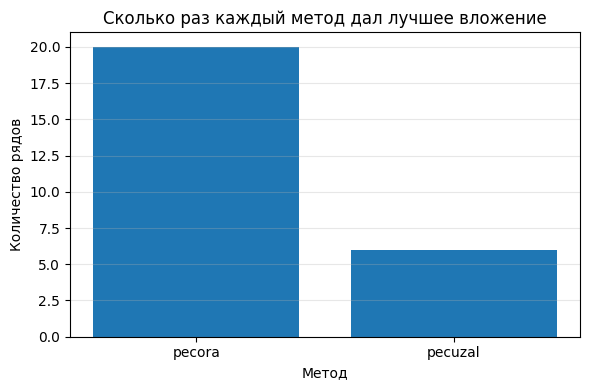

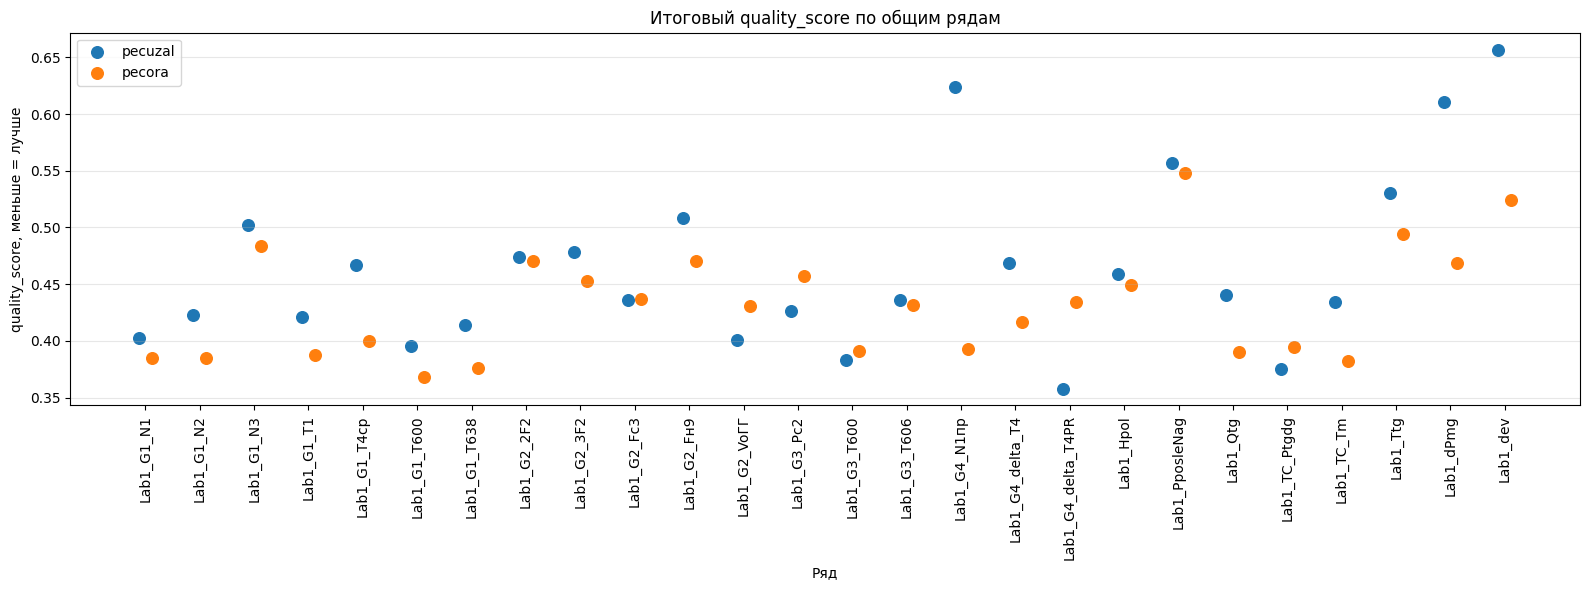

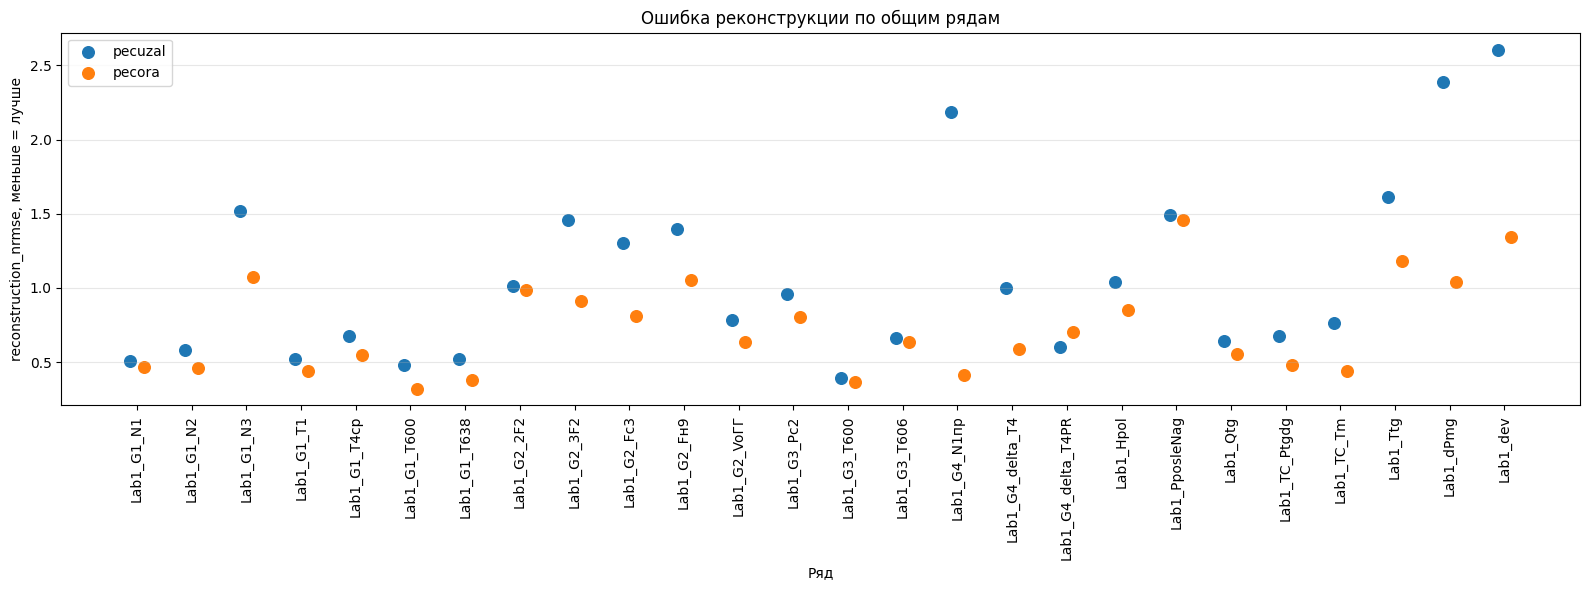

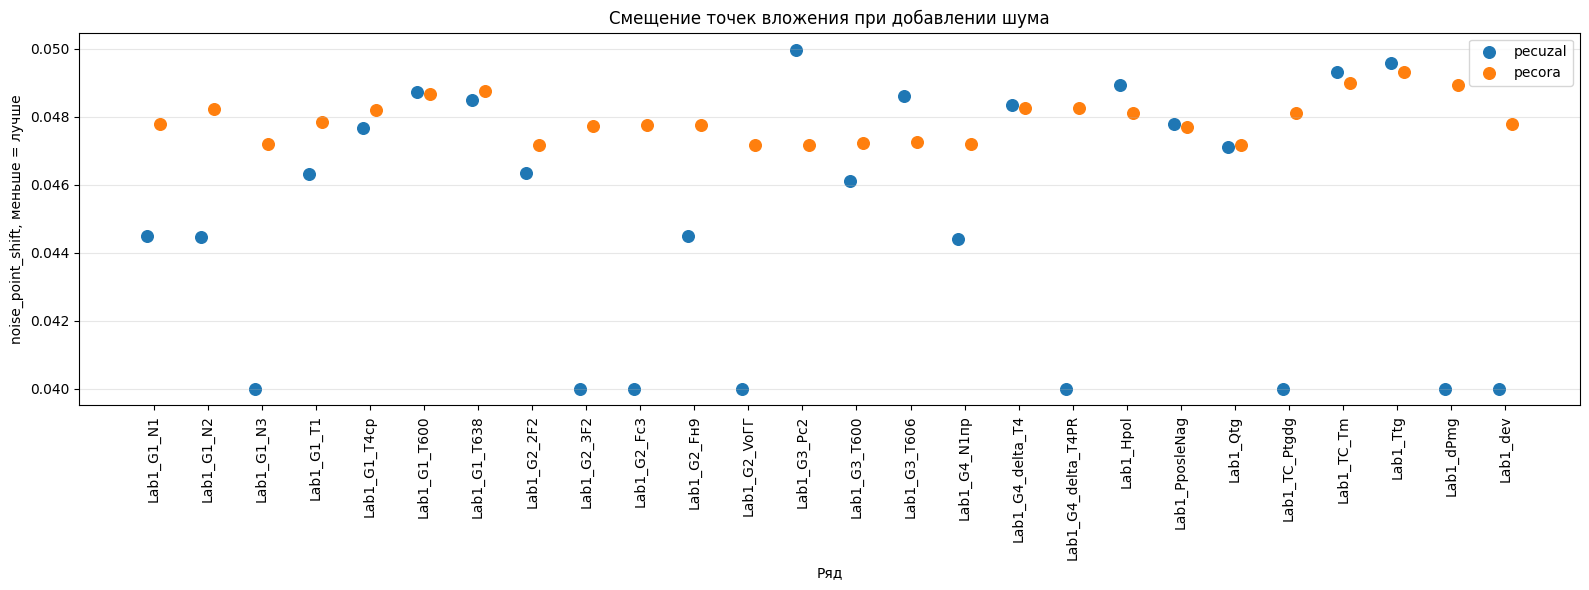

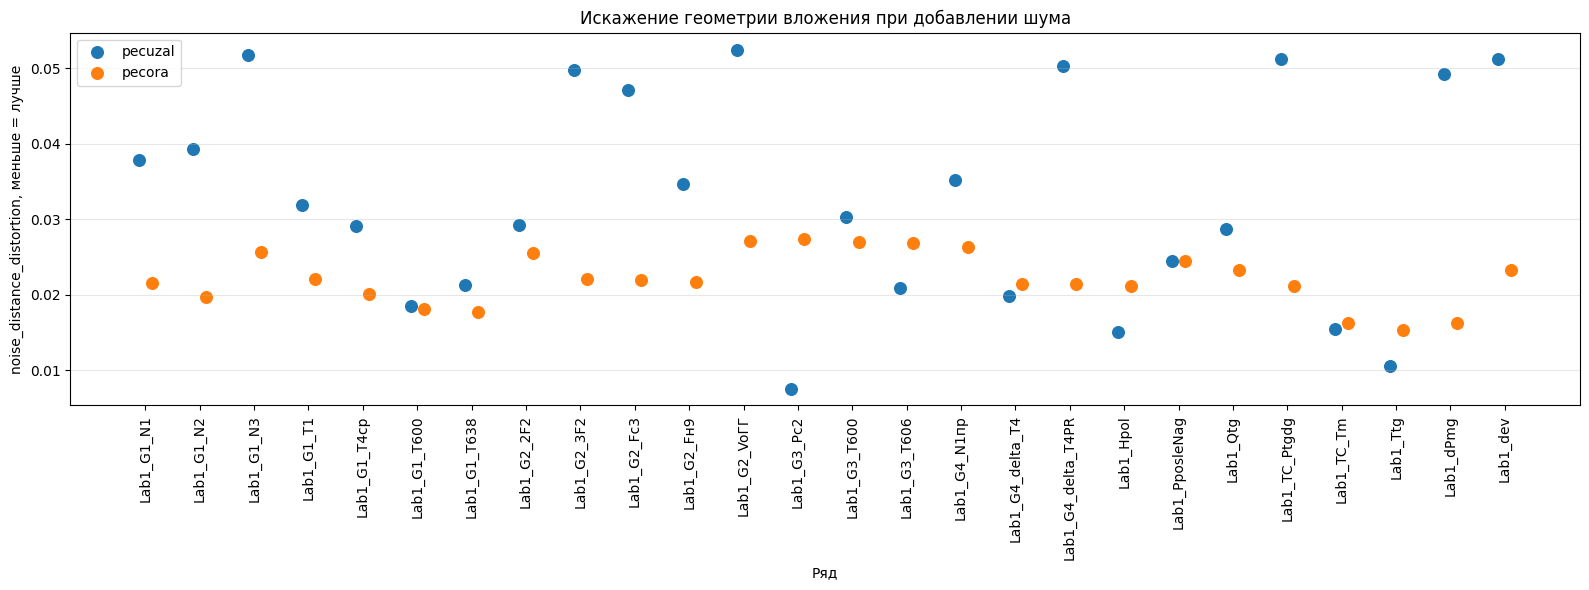

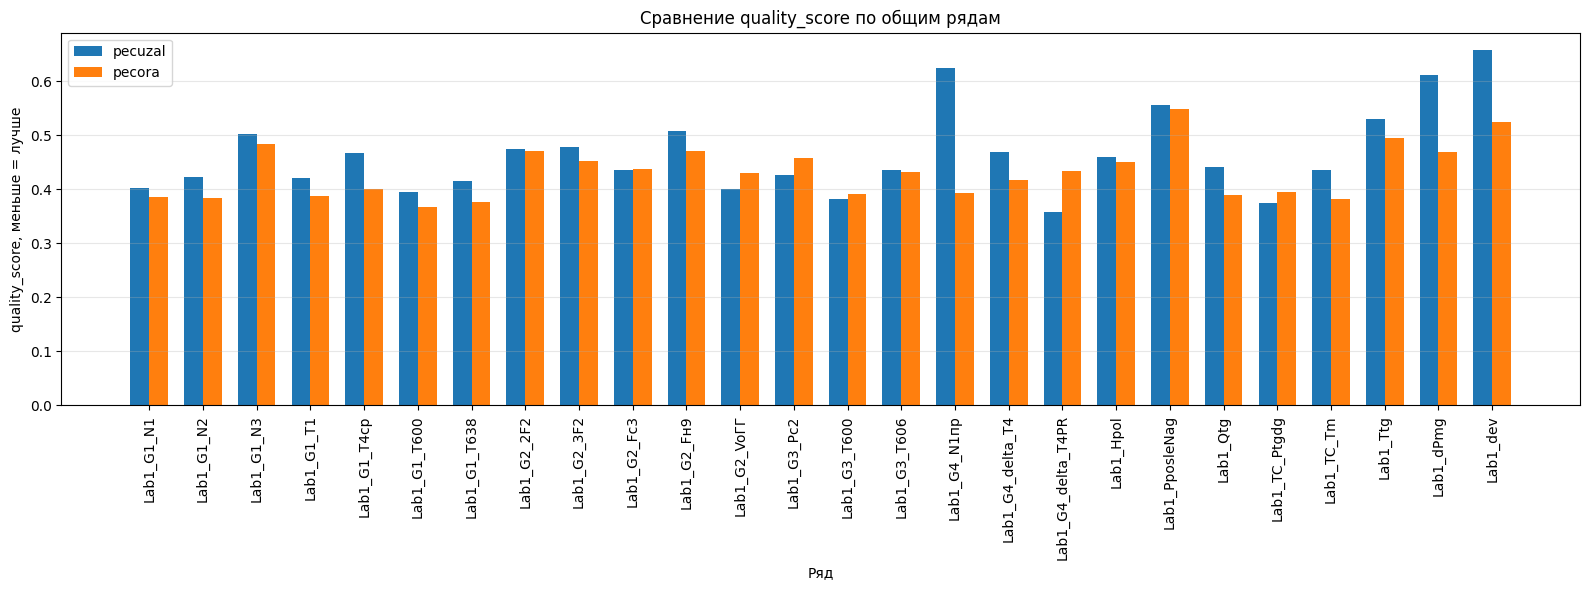

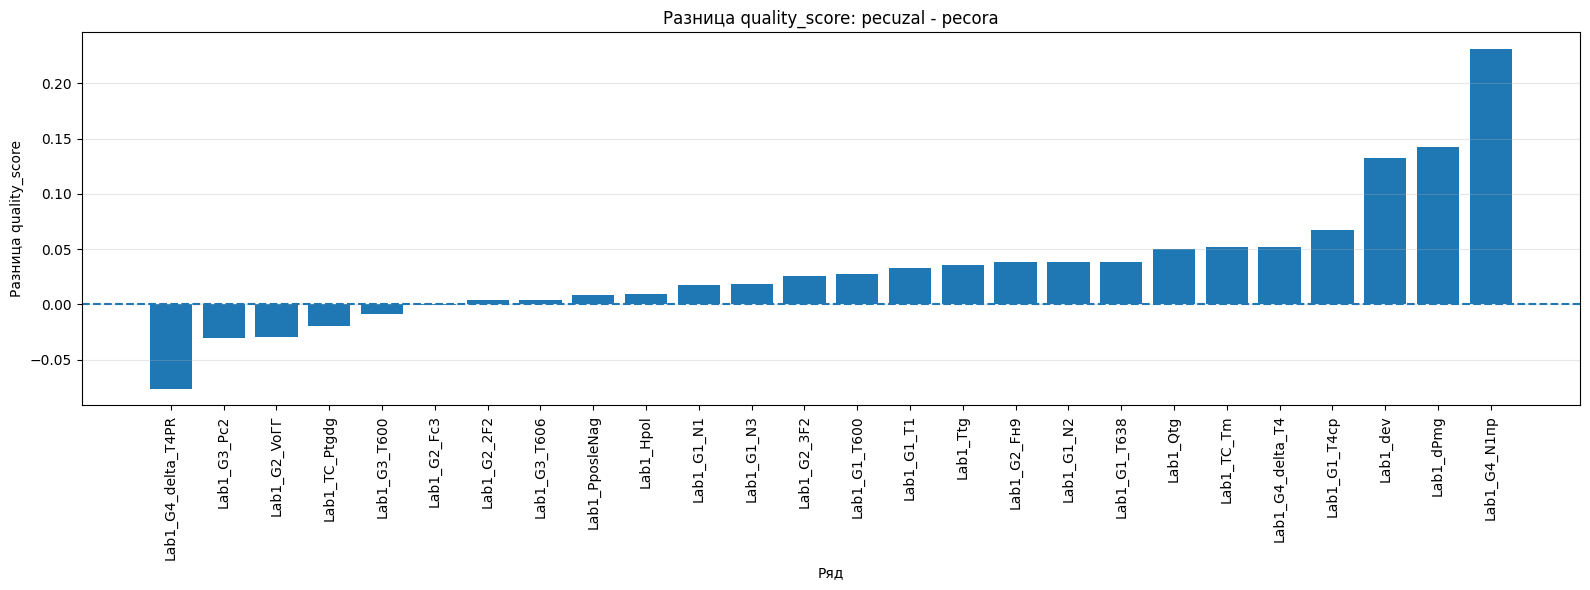

,column,best_method,quality_score_pecuzal,quality_score_pecora,quality_score_diff_pecuzal_minus_pecora,reconstruction_nrmse_pecuzal,reconstruction_nrmse_pecora,noise_point_shift_pecuzal,noise_point_shift_pecora,noise_distance_distortion_pecuzal,noise_distance_distortion_pecora
7,Lab1_G2_2F2,pecora,0.473622,0.470107,0.003515,1.013359,0.988094,0.046345,0.047178,0.029237,0.025509
14,Lab1_G3_T606,pecora,0.435677,0.431289,0.004388,0.661938,0.635406,0.048603,0.047263,0.020858,0.026829
19,Lab1_PposleNag,pecora,0.556489,0.548076,0.008412,1.490796,1.459615,0.047785,0.047696,0.024534,0.024414
18,Lab1_Hpol,pecora,0.458695,0.449510,0.009185,1.039203,0.854049,0.048926,0.048120,0.015091,0.021122
0,Lab1_G1_N1,pecora,0.402542,0.384805,0.017737,0.508515,0.465749,0.044502,0.047791,0.037885,0.021518
2,Lab1_G1_N3,pecora,0.502474,0.483971,0.018503,1.517671,1.075617,0.040001,0.047189,0.051792,0.025607
8,Lab1_G2_3F2,pecora,0.478452,0.452424,0.026028,1.456451,0.913940,0.040001,0.047732,0.049757,0.022085
5,Lab1_G1_T600,pecora,0.395306,0.367746,0.027560,0.479864,0.321716,0.048725,0.048663,0.018451,0.018120
3,Lab1_G1_T1,pecora,0.420933,0.387569,0.033364,0.521475,0.439438,0.046325,0.047856,0.031898,0.022116
23,Lab1_Ttg,pecora,0.530198,0.494521,0.035677,1.610278,1.179384,0.049576,0.049322,0.010572,0.015377


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# =========================
# 1. ЧИТАЕМ РЕЗУЛЬТАТЫ
# =========================

full = pd.read_csv("nonuniform_embedding_quality_full.csv")
summary = pd.read_csv("nonuniform_embedding_quality_summary.csv")
best = pd.read_csv("nonuniform_embedding_quality_best_by_column.csv")

print("Количество строк по методам:")
print(full["method"].value_counts())

print("\nКоличество уникальных рядов по методам:")
print(full.groupby("method")["column"].nunique())

print("\nДубли по column + method:")
duplicates = (
    full.groupby(["column", "method"])
    .size()
    .reset_index(name="count")
    .query("count > 1")
)
display(duplicates)

print("\nСводка по методам:")
display(summary)


# =========================
# 2. ОСТАВЛЯЕМ ТОЛЬКО ОБЩИЕ РЯДЫ
# =========================
# То есть только те ряды, где есть и pecuzal, и pecora.

required_methods = {"pecuzal", "pecora"}

methods_by_column = (
    full.groupby("column")["method"]
    .apply(lambda x: set(x))
)

common_columns = methods_by_column[
    methods_by_column.apply(lambda methods: required_methods.issubset(methods))
].index

full_common = full[full["column"].isin(common_columns)].copy()
full_common = full_common[full_common["method"].isin(required_methods)].copy()

print("\nВсего строк в исходном full:", len(full))
print("Общих рядов, где есть оба метода:", len(common_columns))
print("Строк после фильтрации:", len(full_common))

print("\nКоличество строк по методам после фильтрации:")
print(full_common["method"].value_counts())

print("\nКоличество уникальных рядов по методам после фильтрации:")
print(full_common.groupby("method")["column"].nunique())


# =========================
# 3. ТАБЛИЦА ПО ОБЩИМ РЯДАМ
# =========================

cols_to_show = [
    "column",
    "method",
    "dimension",
    "lags_str",
    "cost",
    "reconstruction_nrmse",
    "noise_point_shift",
    "noise_distance_distortion",
    "quality_score"
]

comparison_table = (
    full_common[cols_to_show]
    .sort_values(["column", "method"])
    .reset_index(drop=True)
)

display(comparison_table)


# =========================
# 4. WIDE-ФОРМАТ ДЛЯ СРАВНЕНИЯ
# =========================

wide = full_common.pivot_table(
    index="column",
    columns="method",
    values=[
        "dimension",
        "reconstruction_nrmse",
        "noise_point_shift",
        "noise_distance_distortion",
        "quality_score"
    ],
    aggfunc="first"
)

wide.columns = [f"{metric}_{method}" for metric, method in wide.columns]
wide = wide.reset_index()

wide = wide.dropna(
    subset=[
        "quality_score_pecuzal",
        "quality_score_pecora"
    ]
).copy()

wide["quality_score_diff_pecuzal_minus_pecora"] = (
    wide["quality_score_pecuzal"] - wide["quality_score_pecora"]
)

wide["best_method"] = np.where(
    wide["quality_score_pecuzal"] < wide["quality_score_pecora"],
    "pecuzal",
    "pecora"
)

display(wide)


# =========================
# 5. СКОЛЬКО РАЗ КАКОЙ МЕТОД ЛУЧШЕ
# =========================

method_counts = wide["best_method"].value_counts()

display(method_counts.to_frame("wins"))

plt.figure(figsize=(6, 4))
plt.bar(method_counts.index, method_counts.values)
plt.title("Сколько раз каждый метод дал лучшее вложение")
plt.ylabel("Количество рядов")
plt.xlabel("Метод")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# =========================
# 6. ФУНКЦИЯ ДЛЯ ТОЧЕЧНЫХ ГРАФИКОВ
# =========================

def scatter_metric_by_method(df, metric, title, ylabel):
    plt.figure(figsize=(16, 6))

    columns_order = sorted(df["column"].unique())
    x_positions = {col: i for i, col in enumerate(columns_order)}

    offsets = {
        "pecuzal": -0.12,
        "pecora": 0.12
    }

    for method in ["pecuzal", "pecora"]:
        method_df = df[df["method"] == method].copy()
        method_df = method_df.sort_values("column")

        x = [
            x_positions[col] + offsets.get(method, 0.0)
            for col in method_df["column"]
        ]

        plt.scatter(
            x,
            method_df[metric],
            label=method,
            s=70
        )

    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("Ряд")
    plt.xticks(
        range(len(columns_order)),
        columns_order,
        rotation=90
    )
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================
# 7. QUALITY SCORE
# =========================

scatter_metric_by_method(
    full_common,
    metric="quality_score",
    title="Итоговый quality_score по общим рядам",
    ylabel="quality_score, меньше = лучше"
)


# =========================
# 8. RECONSTRUCTION NRMSE
# =========================

scatter_metric_by_method(
    full_common,
    metric="reconstruction_nrmse",
    title="Ошибка реконструкции по общим рядам",
    ylabel="reconstruction_nrmse, меньше = лучше"
)


# =========================
# 9. NOISE POINT SHIFT
# =========================

scatter_metric_by_method(
    full_common,
    metric="noise_point_shift",
    title="Смещение точек вложения при добавлении шума",
    ylabel="noise_point_shift, меньше = лучше"
)


# =========================
# 10. NOISE DISTANCE DISTORTION
# =========================

scatter_metric_by_method(
    full_common,
    metric="noise_distance_distortion",
    title="Искажение геометрии вложения при добавлении шума",
    ylabel="noise_distance_distortion, меньше = лучше"
)


# =========================
# 11. СТОЛБИКИ QUALITY SCORE ПО ОБЩИМ РЯДАМ
# =========================

wide_plot = wide.sort_values("column").copy()

x = np.arange(len(wide_plot))
width = 0.35

plt.figure(figsize=(16, 6))

plt.bar(
    x - width / 2,
    wide_plot["quality_score_pecuzal"],
    width,
    label="pecuzal"
)

plt.bar(
    x + width / 2,
    wide_plot["quality_score_pecora"],
    width,
    label="pecora"
)

plt.title("Сравнение quality_score по общим рядам")
plt.ylabel("quality_score, меньше = лучше")
plt.xlabel("Ряд")
plt.xticks(x, wide_plot["column"], rotation=90)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# =========================
# 12. РАЗНИЦА QUALITY SCORE
# =========================
# diff < 0  -> лучше pecuzal
# diff > 0  -> лучше pecora

diff_plot = wide.sort_values("quality_score_diff_pecuzal_minus_pecora").copy()

plt.figure(figsize=(16, 6))

plt.bar(
    diff_plot["column"],
    diff_plot["quality_score_diff_pecuzal_minus_pecora"]
)

plt.axhline(0, linestyle="--")

plt.title("Разница quality_score: pecuzal - pecora")
plt.ylabel("Разница quality_score")
plt.xlabel("Ряд")
plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# =========================
# 13. ТАБЛИЦА ЛУЧШИХ МЕТОДОВ ПО ОБЩИМ РЯДАМ
# =========================

best_table = wide[
    [
        "column",
        "best_method",
        "quality_score_pecuzal",
        "quality_score_pecora",
        "quality_score_diff_pecuzal_minus_pecora",
        "reconstruction_nrmse_pecuzal",
        "reconstruction_nrmse_pecora",
        "noise_point_shift_pecuzal",
        "noise_point_shift_pecora",
        "noise_distance_distortion_pecuzal",
        "noise_distance_distortion_pecora"
    ]
].copy()

best_table = best_table.sort_values(
    ["best_method", "quality_score_diff_pecuzal_minus_pecora"]
)

display(best_table)